In [28]:
import os
import warnings

import agama
import astropy
import cmasher as cmr
import gc_utils
import gizmo_analysis as gizmo
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import utilities as ut
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm, Normalize
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde, lognorm, norm
from sklearn.svm import SVC, LinearSVC

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [29]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_cmap = plt.get_cmap("tab10")
sim_colors = [sim_cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

snapz0 = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = np.array(pub_data["index"])
time_lst = np.array(pub_data["time_Gyr"])
timez0 = np.array(pub_data["time_Gyr"])[-1]

In [37]:
sim_dict = {}
for sim in sim_lst:
    print(sim)
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

        amsk = src_dat["grpid"][()] == 0
        grpid = src_dat["grpid"][()]
        # samsk =

        m_tfo = 10 ** src_dat["logm_tfor"][()]
        m_tfo_ev = 0.55 * (10 ** src_dat["logm_tfor"][()])

        m_tz0_log = src_dat["logm_tz0"][()]
        m_tz0 = np.array([10**x if x != -1 else 0 for x in m_tz0_log])

        tfor = src_dat["tfor"][()]
        tdis = src_dat["tdis"][()]
        tacc = src_dat["tacc"][()]
        pxyz_snap600 = src_dat["pxyz_snap600"][()]

        r_bir = src_dat["halo.r.birth"][()]

        age = timez0 - tfor
        age_p = np.array([x - y if x != -1 else timez0 - y for x, y in zip(tdis, tfor)])

        t_tz0 = src_dat["torb_600"][()]
        s_tz0 = np.array(src_dat["s_flag"][()], dtype=bool)
        samsk = np.array(src_dat["sa_flag"][()], dtype=bool)

        ml = m_tfo_ev - m_tz0
        ml_rate = (m_tfo_ev - m_tz0) / age_p

        sim_dict[sim][it_id] = {}
        sim_dict[sim][it_id]["m_tfo"] = m_tfo
        sim_dict[sim][it_id]["m_tfo_ev"] = m_tfo_ev
        sim_dict[sim][it_id]["m_tz0"] = m_tz0
        sim_dict[sim][it_id]["tfor"] = tfor
        sim_dict[sim][it_id]["tdis"] = tdis
        sim_dict[sim][it_id]["tacc"] = tacc
        sim_dict[sim][it_id]["age"] = age
        sim_dict[sim][it_id]["age_p"] = age_p
        sim_dict[sim][it_id]["t_tz0"] = t_tz0
        sim_dict[sim][it_id]["s_tz0"] = s_tz0
        sim_dict[sim][it_id]["ml"] = ml
        sim_dict[sim][it_id]["ml_rate"] = ml_rate
        sim_dict[sim][it_id]["acc"] = amsk
        sim_dict[sim][it_id]["grp"] = grpid
        sim_dict[sim][it_id]["samsk"] = samsk
        sim_dict[sim][it_id]["r_bir"] = r_bir
        sim_dict[sim][it_id]["pos_z0"] = pxyz_snap600
        sim_dict[sim][it_id]["feh"] = src_dat["feh"][()]

In [38]:
sim = "m12i"
it_id = "it001"

r3d = np.linalg.norm(sim_dict[sim][it_id]["pos_z0"], axis=1)

r2d = np.sqrt(sim_dict[sim][it_id]["pos_z0"][:, 0] ** 2 + sim_dict[sim][it_id]["pos_z0"][:, 1] ** 2)
phi = np.arctan2(sim_dict[sim][it_id]["pos_z0"][:, 1], sim_dict[sim][it_id]["pos_z0"][:, 0])  # in radians
z_cyl = sim_dict[sim][it_id]["pos_z0"][:, 2]

In [39]:
np.min(r3d), np.max(r3d)

(0.04289439688381428, 306.68476189798827)

In [40]:
# r3d_bins = np.logspace(-3, 2.8, 12)
# r3d_centers = np.sqrt(r3d_bins[:-1] * r3d_bins[1:])
# r3d_bins = np.arange(0, 360, 15)
r3d_bins = np.arange(0, 100, 2)
r3d_centers = r3d_bins[:-1] + np.diff(r3d_bins) / 2

plot_dict = {
    sim: {
        it_id: {"in_a": [], "in_d": [], "ex_a": [], "ex_da": [], "ex_dd": []}
        for it_id in sim_dict[sim].keys()
    }
    for sim in sim_lst
}

for sim in plot_dict.keys():
    for it_id in plot_dict[sim].keys():
        r3d = np.linalg.norm(sim_dict[sim][it_id]["pos_z0"], axis=1)
        # age = timez0 - sim_dict[sim][it_id]["tfor"]
        age = sim_dict[sim][it_id]["tfor"]
        mfor = sim_dict[sim][it_id]["m_tfo"]
        feh = sim_dict[sim][it_id]["feh"]
        age_p = sim_dict[sim][it_id]["age_p"]
        for i in range(1, len(r3d_bins)):
            bmin = r3d_bins[i - 1]
            bmax = r3d_bins[i]
            bmsk = (bmin <= r3d) & (r3d < bmax)

            smsk = sim_dict[sim][it_id]["s_tz0"]
            samsk = sim_dict[sim][it_id]["samsk"]
            amsk = sim_dict[sim][it_id]["acc"]

            plot_dict[sim][it_id]["in_a"].append(np.nanmean(feh[bmsk & amsk & smsk]))
            plot_dict[sim][it_id]["in_d"].append(np.nanmean(feh[bmsk & amsk & ~smsk]))

            plot_dict[sim][it_id]["ex_a"].append(np.nanmean(feh[bmsk & ~amsk & smsk]))
            plot_dict[sim][it_id]["ex_da"].append(np.nanmean(feh[bmsk & ~amsk & ~smsk & samsk]))
            plot_dict[sim][it_id]["ex_dd"].append(np.nanmean(feh[bmsk & ~amsk & ~smsk & ~samsk]))

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1102114513.py:35: RuntimeWarning: Mean of empty slice
  plot_dict[sim][it_id]["ex_a"].append(np.nanmean(feh[bmsk & ~amsk & smsk]))
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1102114513.py:32: RuntimeWarning: Mean of empty slice
  plot_dict[sim][it_id]["in_a"].append(np.nanmean(feh[bmsk & amsk & smsk]))
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1102114513.py:33: RuntimeWarning: Mean of empty slice
  plot_dict[sim][it_id]["in_d"].append(np.nanmean(feh[bmsk & amsk & ~smsk]))
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1102114513.py:36: RuntimeWarning: Mean of empty slice
  plot_dict[sim][it_id]["ex_da"].append(np.nanmean(feh[bmsk & ~amsk & ~smsk & samsk]))


/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1670824899.py:9: RuntimeWarning: Mean of empty slice
  in_a_avg = np.nanmean([plot_dict[sim][it_id]["in_a"] for it_id in plot_dict[sim].keys()], axis=0)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1670824899.py:10: RuntimeWarning: Mean of empty slice
  in_d_avg = np.nanmean([plot_dict[sim][it_id]["in_d"] for it_id in plot_dict[sim].keys()], axis=0)
/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_94887/1670824899.py:12: RuntimeWarning: Mean of empty slice
  ex_a_avg = np.nanmean([plot_dict[sim][it_id]["ex_a"] for it_id in plot_dict[sim].keys()], axis=0)


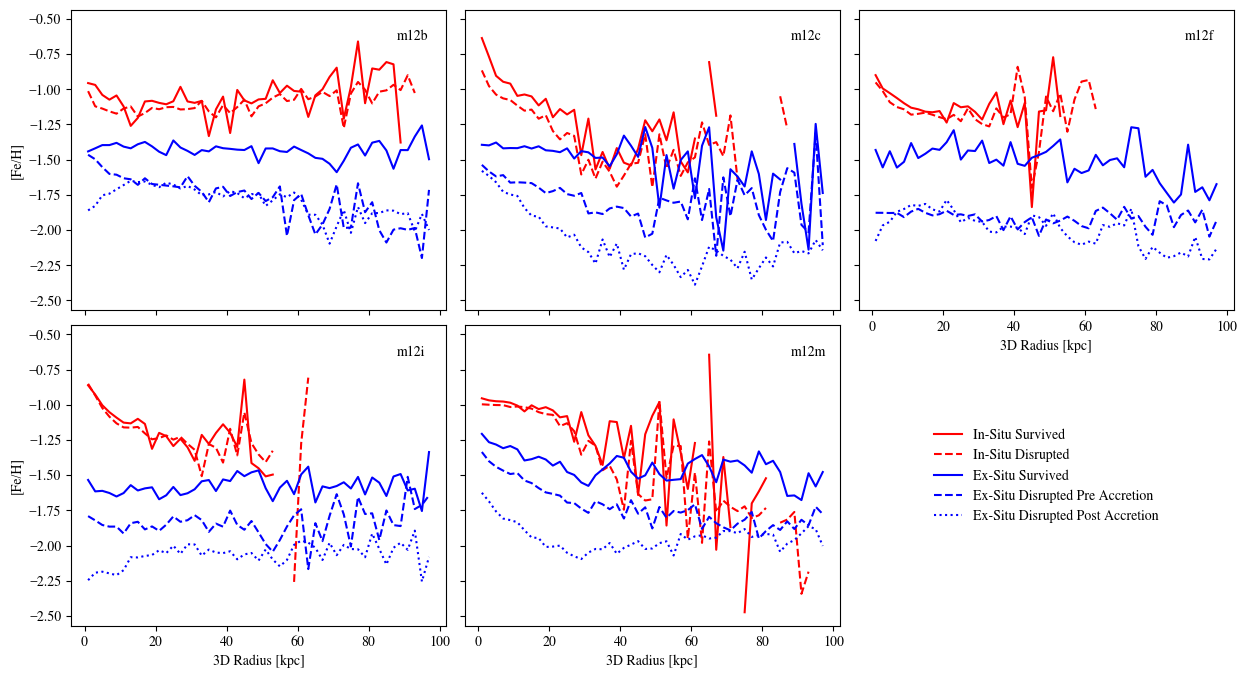

In [41]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.05, wspace=0.05)

axs_flat = axs.flatten()

for k, sim in enumerate(sim_lst):
    ax = axs_flat[k]

    in_a_avg = np.nanmean([plot_dict[sim][it_id]["in_a"] for it_id in plot_dict[sim].keys()], axis=0)
    in_d_avg = np.nanmean([plot_dict[sim][it_id]["in_d"] for it_id in plot_dict[sim].keys()], axis=0)

    ex_a_avg = np.nanmean([plot_dict[sim][it_id]["ex_a"] for it_id in plot_dict[sim].keys()], axis=0)
    ex_da_avg = np.nanmean([plot_dict[sim][it_id]["ex_da"] for it_id in plot_dict[sim].keys()], axis=0)
    ex_dd_avg = np.nanmean([plot_dict[sim][it_id]["ex_dd"] for it_id in plot_dict[sim].keys()], axis=0)

    ax.plot(r3d_centers, in_a_avg, c="r", ls="-", label="In-Situ Survived")
    ax.plot(r3d_centers, in_d_avg, c="r", ls="--", label="In-Situ Disrupted")

    ax.plot(r3d_centers, ex_a_avg, c="b", ls="-", label="Ex-Situ Survived")
    ax.plot(r3d_centers, ex_da_avg, c="b", ls="--", label="Ex-Situ Disrupted Pre Accretion")
    ax.plot(r3d_centers, ex_dd_avg, c="b", ls="dotted", label="Ex-Situ Disrupted Post Accretion")

    ax.text(
        0.87,
        0.90,
        sim,
        transform=ax.transAxes,
        # fontsize=12,
        color="k",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )

    # ax.set_yscale("log")

    if k > 1:
        ax.set_xlabel(r"3D Radius [kpc]")

    if (k == 0) or (k == 3):
        # ax.set_ylabel(r"Age (At Disruption) [Gyr]")
        ax.set_ylabel(r"[Fe/H]")
        # ax.set_ylabel(r"Mass at Formation [M$_{\odot}$]")

axs[0, 2].tick_params(labelbottom=True)

# ---- Empty subplot becomes colorbar container ----
empty_ax = axs[1, 2]
empty_ax.axis("off")  # hide frame & ticks

# get handles + labels from first axis
handles, labels = axs_flat[0].get_legend_handles_labels()

empty_ax.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
)

# ax.set_ylim(0, 14)
# ax.set_yscale("log")

In [35]:
sim = "m12i"

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------
xlim = (0, 0.2)
# ylim = (0, 0.85)
ylim = (0, 0.5)
min_gc_per_grp_avg = 5  # average minimum GCs per group across iterations
epsilon = 1e-6  # tiny jitter for KDE stability
cmap = plt.get_cmap("viridis")  # colormap

# --------------------------------------------------
# COMPUTE GROUP COUNTS AND TACC ACROSS ITERATIONS
# --------------------------------------------------
grp_counts = {}  # key = grp, value = list of counts per iteration
grp_tacc = {}  # key = grp, value = list of tacc values

for it_id in mass_dict[sim].keys():
    counts_in_it = {}
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue
        counts_in_it[grp] = counts_in_it.get(grp, 0) + 1
        grp_tacc.setdefault(grp, []).append(tacc)
    # append counts per iteration
    for grp, cnt in counts_in_it.items():
        grp_counts.setdefault(grp, []).append(cnt)

# Only keep groups with average ≥ min_gc_per_grp_avg
valid_grps = [grp for grp, counts in grp_counts.items() if np.mean(counts) >= min_gc_per_grp_avg]

# --------------------------------------------------
# BIN DATA BY GROUP
# --------------------------------------------------
binned_data = {grp: {"gamma_pre": [], "gamma_pos": [], "tacc": None} for grp in valid_grps}

for grp in valid_grps:
    # mean tacc for the group
    binned_data[grp]["tacc"] = np.mean(grp_tacc[grp])

for it_id in mass_dict[sim].keys():
    for gcid in mass_dict[sim][it_id].keys():
        grp = mass_dict[sim][it_id][gcid]["grp"]
        if grp not in valid_grps:
            continue  # skip invalid groups
        tacc = mass_dict[sim][it_id][gcid]["tacc"]
        if tacc == -1:
            continue  # only accreted GCs
        binned_data[grp]["gamma_pre"].append(mass_dict[sim][it_id][gcid]["gamma_pre"])
        binned_data[grp]["gamma_pos"].append(mass_dict[sim][it_id][gcid]["gamma_pos"])


# --------------------------------------------------
# FUNCTION TO COMPUTE CONTOUR LEVEL (CDF METHOD)
# --------------------------------------------------
def kde_cdf_level(Z, frac=0.75):
    Zf = Z.ravel()
    idx = np.argsort(Zf)[::-1]
    Zs = Zf[idx]
    cdf = np.cumsum(Zs)
    cdf /= cdf[-1]
    return Zs[np.searchsorted(cdf, frac)]


fig, ax = plt.subplots(figsize=(8, 6))

all_tacc = [data["tacc"] for data in binned_data.values()]
if len(all_tacc) == 0:
    raise RuntimeError("No valid groups to plot! Check your min_gc_per_grp_avg or data.")
norm = plt.Normalize(vmin=0, vmax=14)

xgrid = np.linspace(*xlim, 100)
ygrid = np.linspace(*ylim, 100)
X, Y = np.meshgrid(xgrid, ygrid)
grid_positions = np.vstack([X.ravel(), Y.ravel()])

for grp, data in binned_data.items():
    Z_list = []

    for it_id in mass_dict[sim].keys():
        # collect per-iteration points
        x_it, y_it = [], []

        for gcid in mass_dict[sim][it_id].keys():
            g = mass_dict[sim][it_id][gcid]["grp"]
            if g != grp:
                continue

            tacc = mass_dict[sim][it_id][gcid]["tacc"]
            if tacc == -1:
                continue

            x_it.append(mass_dict[sim][it_id][gcid]["gamma_pre"])
            y_it.append(mass_dict[sim][it_id][gcid]["gamma_pos"])

        x_it = np.array(x_it)
        y_it = np.array(y_it)

        mask = np.isfinite(x_it) & np.isfinite(y_it)
        x_it, y_it = x_it[mask], y_it[mask]

        if len(x_it) < 5:
            continue

        # jitter
        x_it += np.random.normal(0, epsilon, len(x_it))
        y_it += np.random.normal(0, epsilon, len(y_it))

        # KDE per iteration
        kde = gaussian_kde(np.vstack([x_it, y_it]))
        Z = kde(grid_positions).reshape(X.shape)

        Z /= Z.sum()
        Z_list.append(Z)

    if len(Z_list) == 0:
        continue

    # --------------------------------------------------
    # Average KDE
    # --------------------------------------------------
    Z_avg = np.mean(Z_list, axis=0)

    # --------------------------------------------------
    # 75% contour (CDF-based)
    # --------------------------------------------------
    level_75 = kde_cdf_level(Z_avg, frac=0.75)

    ax.contour(
        X,
        Y,
        Z_avg,
        levels=[level_75],
        colors=[cmap(norm(data["tacc"]))],
        linewidths=2,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Time of Accretion (Gyr)")

ax.plot([0, 1], [0, 1], c="grey", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel("Pre Accretion Decay Rate (Gyr$^{-1}$)")
ax.set_ylabel("Post Accretion Decay Rate (Gyr$^{-1}$)")


# Put ticks on top (optional, looks nicer for top colorbar)
# cax.xaxis.set_ticks_position("top")
# cax.xaxis.set_label_position("top")

for tacc in all_tacc:
    cbar.ax.axhline(tacc, color="w", lw=2.0, ls="-")

NameError: name 'mass_dict' is not defined

Aurora:

https://academic.oup.com/mnras/article/514/1/689/6584853

In [ ]:
sim_dir_ext = "/Volumes/Expansion/simulations/"

In [ ]:
sim = "m12i"

fire_dir = sim_dir_ext + sim + "/" + sim + "_res7100/"
part = gc_utils.open_snapshot(snapz0, fire_dir, "star")

Retrieving Snapshot 600..................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]


OSError: cannot find snapshot index = 600 in:  []

In [ ]:
rpart = part["star"].prop("host.distance.total.principal")

# mass_dict = {sim: {it_id: []}}